# Logistic Regression (Regressão Logística)

## Table of Contents
* [Libraries](#Libraries-(Bibliotecas))
* [Leitura e Preparação dos Dados](#Leitura-e-Preparação-dos-Dados)
* [Logistic Regression Model](#Logistic-Regression-Model)
* [Análise de Erro](#Análise-de-Erro)
* [Retreinando o Modelo](#Retreinando-o-Modelo)
* [Criando o Resultado das Previsões para Importar ao Kaggle](#Criando-o-Resultado-das-Previsões-para-Importar-ao-Kaggle)

## Libraries (Bibliotecas)

In [5]:
import pandas as pd
import numpy as np
%matplotlib inline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import StandardScaler

## Leitura e Preparação dos Dados

In [7]:
train = pd.read_csv('../dataset/train.csv')
test = pd.read_csv('../dataset/test.csv')
print(f'Train set shape: {train.shape}\nTest set shape: {test.shape}')

Train set shape: (891, 12)
Test set shape: (418, 11)


In [8]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [14]:
train['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [16]:
train['Sex_b'] = train['Sex'].map(lambda x: 1 if x == 'female' else 0)
test['Sex_b'] = test['Sex'].map(lambda x: 1 if x == 'female' else 0)

In [18]:
train['Sex_b'].value_counts()

Sex_b
0    577
1    314
Name: count, dtype: int64

In [20]:
list(train['Cabin'].unique())

[nan,
 'C85',
 'C123',
 'E46',
 'G6',
 'C103',
 'D56',
 'A6',
 'C23 C25 C27',
 'B78',
 'D33',
 'B30',
 'C52',
 'B28',
 'C83',
 'F33',
 'F G73',
 'E31',
 'A5',
 'D10 D12',
 'D26',
 'C110',
 'B58 B60',
 'E101',
 'F E69',
 'D47',
 'B86',
 'F2',
 'C2',
 'E33',
 'B19',
 'A7',
 'C49',
 'F4',
 'A32',
 'B4',
 'B80',
 'A31',
 'D36',
 'D15',
 'C93',
 'C78',
 'D35',
 'C87',
 'B77',
 'E67',
 'B94',
 'C125',
 'C99',
 'C118',
 'D7',
 'A19',
 'B49',
 'D',
 'C22 C26',
 'C106',
 'C65',
 'E36',
 'C54',
 'B57 B59 B63 B66',
 'C7',
 'E34',
 'C32',
 'B18',
 'C124',
 'C91',
 'E40',
 'T',
 'C128',
 'D37',
 'B35',
 'E50',
 'C82',
 'B96 B98',
 'E10',
 'E44',
 'A34',
 'C104',
 'C111',
 'C92',
 'E38',
 'D21',
 'E12',
 'E63',
 'A14',
 'B37',
 'C30',
 'D20',
 'B79',
 'E25',
 'D46',
 'B73',
 'C95',
 'B38',
 'B39',
 'B22',
 'C86',
 'C70',
 'A16',
 'C101',
 'C68',
 'A10',
 'E68',
 'B41',
 'A20',
 'D19',
 'D50',
 'D9',
 'A23',
 'B50',
 'A26',
 'D48',
 'E58',
 'C126',
 'B71',
 'B51 B53 B55',
 'D49',
 'B5',
 'B20',
 'F G

In [22]:
train['Embarked_S'] = (train['Embarked'] == 'S').astype(int)
train['Embarked_C'] = (train['Embarked'] == 'C').astype(int)

train['Cabin_null'] = train['Cabin'].isnull().astype(int)
train['Cabin_C'] = train['Cabin'].fillna('').str.contains('C').astype(int)
train['Cabin_E'] = train['Cabin'].fillna('').str.contains('E').astype(int)
train['Cabin_G'] = train['Cabin'].fillna('').str.contains('G').astype(int)
train['Cabin_D'] = train['Cabin'].fillna('').str.contains('D').astype(int)
train['Cabin_A'] = train['Cabin'].fillna('').str.contains('A').astype(int)
train['Cabin_B'] = train['Cabin'].fillna('').str.contains('B').astype(int)
train['Cabin_F'] = train['Cabin'].fillna('').str.contains('F').astype(int)
train['Cabin_T'] = train['Cabin'].fillna('').str.contains('T').astype(int)

train['Name_Miss'] = train['Name'].str.contains('Miss.').astype(int)
train['Name_Mrs'] = train['Name'].str.contains('Mrs.').astype(int)
train['Name_Master'] = train['Name'].str.contains('Master.').astype(int)
train['Name_Col'] = train['Name'].str.contains('Col.').astype(int)
train['Name_Major'] = train['Name'].str.contains('Major.').astype(int)
train['Name_Mr'] = train['Name'].str.contains('Mr.').astype(int)
train['Name_Dr'] = train['Name'].str.contains('Dr.').astype(int)
train['Name_Don'] = train['Name'].str.contains('Don.').astype(int)
train['Name_Sir'] = train['Name'].str.contains('Sir.').astype(int)

In [24]:
test['Embarked_S'] = (test['Embarked'] == 'S').astype(int)
test['Embarked_C'] = (test['Embarked'] == 'C').astype(int)

test['Cabin_null'] = test['Cabin'].isnull().astype(int)
test['Cabin_C'] = test['Cabin'].fillna('').str.contains('C').astype(int)
test['Cabin_E'] = test['Cabin'].fillna('').str.contains('E').astype(int)
test['Cabin_G'] = test['Cabin'].fillna('').str.contains('G').astype(int)
test['Cabin_D'] = test['Cabin'].fillna('').str.contains('D').astype(int)
test['Cabin_A'] = test['Cabin'].fillna('').str.contains('A').astype(int)
test['Cabin_B'] = test['Cabin'].fillna('').str.contains('B').astype(int)
test['Cabin_F'] = test['Cabin'].fillna('').str.contains('F').astype(int)
test['Cabin_T'] = test['Cabin'].fillna('').str.contains('T').astype(int)

test['Name_Miss'] = test['Name'].str.contains('Miss.').astype(int)
test['Name_Mrs'] = test['Name'].str.contains('Mrs.').astype(int)
test['Name_Master'] = test['Name'].str.contains('Master.').astype(int)
test['Name_Col'] = test['Name'].str.contains('Col.').astype(int)
test['Name_Major'] = test['Name'].str.contains('Major.').astype(int)
test['Name_Mr'] = test['Name'].str.contains('Mr.').astype(int)
test['Name_Dr'] = test['Name'].str.contains('Dr.').astype(int)
test['Name_Don'] = test['Name'].str.contains('Don.').astype(int)
test['Name_Sir'] = test['Name'].str.contains('Sir.').astype(int)

In [26]:
variaveis = ['Sex_b', 'Age', 'Pclass', 'Embarked_S', 'Embarked_C', 'SibSp', 'Parch', 'Fare', 'Cabin_null',
             'Cabin_C', 'Cabin_E', 'Cabin_G', 'Cabin_D', 'Cabin_A', 'Cabin_B', 'Cabin_F', 'Cabin_T',
             'Name_Miss', 'Name_Mrs', 'Name_Master', 'Name_Col', 'Name_Major', 'Name_Mr', 'Name_Dr', 'Name_Don', 'Name_Sir']

In [30]:
X = train[variaveis].fillna(-1).copy()
X_test = test[variaveis].fillna(-1).copy()
y = train['Survived'].copy()

## Logistic Regression Model

In [17]:
kf = RepeatedKFold(n_splits=3, n_repeats=10, random_state=42)

scaler = StandardScaler()

step_train = []
step = []

for linhas_train, linhas_cv in kf.split(X):
    X_train, X_cv = X.iloc[linhas_train].copy(), X.iloc[linhas_cv].copy()
    y_train, y_cv = y.iloc[linhas_train].copy(), y.iloc[linhas_cv].copy()

    X_train = scaler.fit_transform(X_train)
    X_cv = scaler.transform(X_cv)

    model = LogisticRegression(penalty='l2', random_state=42)
    model.fit(X_train, y_train)

    yhat_train = model.predict(X_train)
    yhat = model.predict(X_cv)

    acc_train = np.mean(y_train == yhat_train)
    acc = np.mean(y_cv == yhat)
    print(f'acc_train: {acc_train:.4f}, acc_cv: {acc:.4f}\n')

    step_train.append(acc_train)
    step.append(acc)

print(f'Train mean: {np.mean(step_train):.2f}, CV mean: {np.mean(step):.2f}')

acc_train: 0.8384, acc_cv: 0.8148

acc_train: 0.8401, acc_cv: 0.8182

acc_train: 0.8418, acc_cv: 0.8148

acc_train: 0.8451, acc_cv: 0.8047

acc_train: 0.8266, acc_cv: 0.8418

acc_train: 0.8468, acc_cv: 0.8148

acc_train: 0.8266, acc_cv: 0.8418

acc_train: 0.8401, acc_cv: 0.8215

acc_train: 0.8418, acc_cv: 0.8316

acc_train: 0.8300, acc_cv: 0.8215

acc_train: 0.8316, acc_cv: 0.8148

acc_train: 0.8485, acc_cv: 0.8215

acc_train: 0.8283, acc_cv: 0.8215

acc_train: 0.8468, acc_cv: 0.8249

acc_train: 0.8502, acc_cv: 0.7845

acc_train: 0.8300, acc_cv: 0.8215

acc_train: 0.8468, acc_cv: 0.8013

acc_train: 0.8283, acc_cv: 0.8182

acc_train: 0.8283, acc_cv: 0.8418

acc_train: 0.8569, acc_cv: 0.7879

acc_train: 0.8249, acc_cv: 0.8418

acc_train: 0.8569, acc_cv: 0.8182

acc_train: 0.8249, acc_cv: 0.8114

acc_train: 0.8384, acc_cv: 0.8182

acc_train: 0.8081, acc_cv: 0.8620

acc_train: 0.8401, acc_cv: 0.8047

acc_train: 0.8603, acc_cv: 0.7912

acc_train: 0.8367, acc_cv: 0.8384

acc_train: 0.8266, a

((array([3., 0., 3., 7., 9., 1., 2., 4., 0., 1.]),
  array([0.78451178, 0.79225589, 0.8       , 0.80774411, 0.81548822,
         0.82323232, 0.83097643, 0.83872054, 0.84646465, 0.85420875,
         0.86195286]),
  <BarContainer object of 10 artists>),
 (array([1., 0., 0., 8., 3., 3., 5., 6., 1., 3.]),
  array([0.80808081, 0.81329966, 0.81851852, 0.82373737, 0.82895623,
         0.83417508, 0.83939394, 0.84461279, 0.84983165, 0.85505051,
         0.86026936]),
  <BarContainer object of 10 artists>))

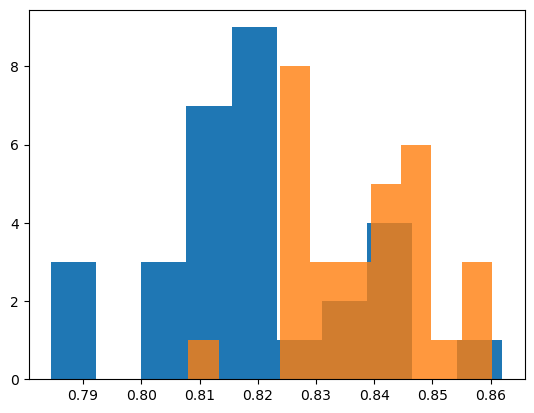

In [18]:
pylab.hist(step), pylab.hist(step_train, alpha=.8)

## Análise de Erro

In [19]:
X_cv_erro = train.iloc[linhas_cv].copy()
X_cv_erro['yhat'] = yhat
X_cv_erro.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Name_Miss,Name_Mrs,Name_Master,Name_Col,Name_Major,Name_Mr,Name_Dr,Name_Don,Name_Sir,yhat
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,...,0,1,0,0,0,1,0,0,0,1
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,...,1,0,0,0,0,0,0,0,0,1
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,...,0,0,1,0,0,0,0,0,0,0
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,...,0,0,0,0,0,1,0,0,0,0
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,...,0,0,0,0,0,1,0,0,0,0


In [20]:
erro = X_cv_erro[X_cv_erro['Survived'] != X_cv_erro['yhat']]
erro = erro[['PassengerId', 'Survived', 'yhat', 'Name', 'Sex', 'Sex_b', 'Embarked', 'Age', 'Ticket', 'Cabin', 'Cabin_null', 'Pclass', 'Embarked_S', 'Embarked_C', 'SibSp', 'Parch', 'Fare', 'Cabin_null',
             'Name_Miss', 'Name_Mrs', 'Name_Master', 'Name_Col', 'Name_Major', 'Name_Mr', 'Name_Dr', 'Name_Don', 'Name_Sir']]
erro.head()

,PassengerId,Survived,yhat,Name,Sex,Sex_b,Embarked,Age,Ticket,Cabin,...,Cabin_null,Name_Miss,Name_Mrs,Name_Master,Name_Col,Name_Major,Name_Mr,Name_Dr,Name_Don,Name_Sir
17,18,1,0,"Williams, Mr. Charles Eugene",male,0,S,NaN,244373,NaN,...,1,0,0,0,0,0,1,0,0,0
23,24,1,0,"Sloper, Mr. William Thompson",male,0,S,28.0,113788,A6,...,0,0,0,0,0,0,1,0,0,0
25,26,1,0,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,1,S,38.0,347077,NaN,...,1,0,1,0,0,0,1,0,0,0
49,50,0,1,"Arnold-Franchi, Mrs. Josef (Josefine Franchi)",female,1,S,18.0,349237,NaN,...,1,0,1,0,0,0,1,0,0,0
68,69,1,0,"Andersson, Miss. Erna Alexandra",female,1,S,17.0,3101281,NaN,...,1,1,0,0,0,0,0,0,0,0


In [21]:
female = erro[erro['Sex_b'] == 1]
male = erro[erro['Sex_b'] == 0]

In [22]:
female.sort_values('Survived')

,PassengerId,Survived,yhat,Name,Sex,Sex_b,Embarked,Age,Ticket,Cabin,...,Cabin_null,Name_Miss,Name_Mrs,Name_Master,Name_Col,Name_Major,Name_Mr,Name_Dr,Name_Don,Name_Sir
312,313,0,1,"Lahtinen, Mrs. William (Anna Sylfven)",female,1,S,26.0,250651,NaN,...,1,0,1,0,0,0,1,0,0,0
772,773,0,1,"Mack, Mrs. (Mary)",female,1,S,57.0,S.O./P.P. 3,E77,...,0,0,1,0,0,0,1,0,0,0
767,768,0,1,"Mangan, Miss. Mary",female,1,Q,30.5,364850,NaN,...,1,1,0,0,0,0,0,0,0,0
657,658,0,1,"Bourke, Mrs. John (Catherine)",female,1,Q,32.0,364849,NaN,...,1,0,1,0,0,0,1,0,0,0
578,579,0,1,"Caram, Mrs. Joseph (Maria Elias)",female,1,C,NaN,2689,NaN,...,1,0,1,0,0,0,1,0,0,0
564,565,0,1,"Meanwell, Miss. (Marion Ogden)",female,1,S,NaN,SOTON/O.Q. 392087,NaN,...,1,1,0,0,0,0,0,0,0,0
502,503,0,1,"O'Sullivan, Miss. Bridget Mary",female,1,Q,NaN,330909,NaN,...,1,1,0,0,0,0,0,0,0,0
501,502,0,1,"Canavan, Miss. Mary",female,1,Q,21.0,364846,NaN,...,1,1,0,0,0,0,0,0,0,0
404,405,0,1,"Oreskovic, Miss. Marija",female,1,S,20.0,315096,NaN,...,1,1,0,0,0,0,0,0,0,0
402,403,0,1,"Jussila, Miss. Mari Aina",female,1,S,21.0,4137,NaN,...,1,1,0,0,0,0,0,0,0,0


In [23]:
male.sort_values('Survived')

,PassengerId,Survived,yhat,Name,Sex,Sex_b,Embarked,Age,Ticket,Cabin,...,Cabin_null,Name_Miss,Name_Mrs,Name_Master,Name_Col,Name_Major,Name_Mr,Name_Dr,Name_Don,Name_Sir
527,528,0,1,"Farthing, Mr. John",male,0,S,NaN,PC 17483,C95,...,0,0,0,0,0,0,1,0,0,0
766,767,0,1,"Brewe, Dr. Arthur Jackson",male,0,C,NaN,112379,NaN,...,1,0,0,0,0,0,0,1,0,0
662,663,0,1,"Colley, Mr. Edward Pomeroy",male,0,S,47.0,5727,E58,...,0,0,0,0,1,0,1,0,0,0
373,374,0,1,"Ringhini, Mr. Sante",male,0,C,22.0,PC 17760,NaN,...,1,0,0,0,0,0,1,0,0,0
557,558,0,1,"Robbins, Mr. Victor",male,0,C,NaN,PC 17757,NaN,...,1,0,0,0,0,0,1,0,0,0
804,805,1,0,"Hedman, Mr. Oskar Arvid",male,0,S,27.0,347089,NaN,...,1,0,0,0,0,0,1,0,0,0
707,708,1,0,"Calderhead, Mr. Edward Pennington",male,0,S,42.0,PC 17476,E24,...,0,0,0,0,0,0,1,0,0,0
692,693,1,0,"Lam, Mr. Ali",male,0,S,NaN,1601,NaN,...,1,0,0,0,0,0,1,0,0,0
690,691,1,0,"Dick, Mr. Albert Adrian",male,0,S,31.0,17474,B20,...,0,0,0,0,0,0,1,0,0,0
645,646,1,0,"Harper, Mr. Henry Sleeper",male,0,C,48.0,PC 17572,D33,...,0,0,0,0,0,0,1,0,0,0


## Retreinando o Modelo

In [24]:
X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

In [25]:
model = LogisticRegression(penalty='l2', random_state=42)
model.fit(X, y)

y_hat = model.predict(X_test)

## Criando o Resultado das Previsões para Importar ao Kaggle

In [26]:
result = pd.Series(y_hat, index=test['PassengerId'], name='Survived')
result

PassengerId
892     0
893     1
894     0
895     0
896     1
       ..
1305    0
1306    0
1307    0
1308    0
1309    1
Name: Survived, Length: 418, dtype: int64

In [ ]:
result_t.to_csv('../yhat/logistic_regression.csv', header=True)